### Fera formidável 4.3 - Derrube pra fora

#### Enunciado:
Objetivo: implemente o regularizador dropout na rede neural feita em Python puro.

Comentário: algumas tarefas vão apresentar palavras e conceitos que ainda não
vimos em sala. Parte do desafio é justamente se informar sobre estes conceitos.

Comentário 2: observe que o enunciado diz claramente que é para realizar a tarefa
na rede neural feita em Python puro nos vídeos da disciplina. Se você está usando o
PyTorch, numpy, tensorflow, keras, lightning ou qualquer outra biblioteca pronta,
você está no caminho errado!

In [119]:
import math
import random
import seaborn as sns
import random as rd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from classes import Valor, Neuronio, Camada, MLP

In [120]:
df = sns.load_dataset("iris")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [121]:
entradas = df.drop(columns=["species", "petal_width"]).values
saidas = df["petal_width"].values.reshape(-1, 1)

In [122]:
TAMANHO_TESTE_E_VALIDACAO = 0.1 

# Alocando 10% dos dados para teste
entradas_temp, entradas_teste, saidas_temp, saidas_teste = train_test_split(
    entradas, saidas, test_size=TAMANHO_TESTE_E_VALIDACAO)

# Alocando 10% dos dados para validação
entradas_treino, entradas_val, saidas_treino, saidas_val = train_test_split(
    entradas_temp, saidas_temp, test_size=TAMANHO_TESTE_E_VALIDACAO)

In [123]:
normalizador = StandardScaler()
x = normalizador.fit_transform(entradas_treino).tolist()
x_val = normalizador.transform(entradas_val).tolist()
x_teste = normalizador.transform(entradas_teste).tolist()

saidas_treino_norm = normalizador.fit_transform(saidas_treino).tolist()
saidas_val_norm = normalizador.transform(saidas_val).tolist()
saidas_teste_norm = normalizador.transform(saidas_teste).tolist()

# Tentar deixar em uma linha só

y_true = []
for i in saidas_treino_norm:
    for j in i:
        y_true.append(j)
        
y_val = []
for i in saidas_val_norm:
    for j in i:
        y_val.append(j)
        
y_teste = []
for i in saidas_teste_norm:
    for j in i:
        y_teste.append(j)

### Dividindo os dados em treino, teste e validação 

In [124]:
NUM_DADOS_DE_ENTRADA = 3
NUM_DADOS_DE_SAIDA = 1
CAMADAS_OCULTAS = [12, 8]  
TAXA_DROPOUT = 0.3

arquitetura_da_rede = CAMADAS_OCULTAS + [NUM_DADOS_DE_SAIDA]

minha_mlp = MLP(NUM_DADOS_DE_ENTRADA, arquitetura_da_rede, taxa_dropout=TAXA_DROPOUT)

In [125]:
NUM_EPOCAS = 200
TAXA_DE_APRENDIZADO = 0.1

x_plot = []
y_plot = []

for epoca in range(NUM_EPOCAS):
    # forward pass
    y_pred = []
    for exemplo in x:
        previsao = minha_mlp(exemplo, treino = True)
        y_pred.append(previsao)
 
    # loss
    erros = []
    
    for yp, yt in zip(y_pred, y_true):
        residuo = yp - yt
        erro_quadratico = residuo ** 2
        erros.append(erro_quadratico)        
    loss = sum(erros)
 
    # zero grad
    for p in minha_mlp.parametros():
        p.grad = 0
 
    # backpropagation
    loss.propagar()
 
    # atualiza parâmetros
    for p in minha_mlp.parametros():
        p.data = p.data - p.grad * TAXA_DE_APRENDIZADO
 
    # mostra resultado (opcional)
    print(epoca, loss.data)
    
    x_plot.append(epoca)
    y_plot.append(loss.data)

0 228.27902415610131
1 208.45419749327974
2 244.81837185408884
3 222.55361270322632
4 221.63890710404868
5 242.43078784158413
6 216.07286584455878
7 224.8266577883122
8 214.90171997450904
9 248.34695678639483
10 241.00761372193546
11 239.61324782223122
12 228.3675939563425
13 214.32961309546693
14 228.07810065047676
15 239.6352333064037
16 227.73526387942366
17 221.24849673733036
18 217.37293589707093
19 234.7769416568177
20 250.10616535026855
21 227.2292248785473
22 228.46971418472182
23 251.82945495544627
24 238.50225018859084
25 233.41487547338258
26 225.21389258259782
27 235.6541667318693
28 214.88132330153275
29 240.08858780396832
30 207.55326637567327
31 252.86971114275258
32 238.11859341661986
33 214.76040893539258
34 235.5853606380432
35 235.55283212901904
36 244.17498351193873
37 238.9602162787341
38 229.3459682879407
39 239.5403649142044
40 231.68717462674752
41 214.67952288312097
42 235.60012429780775
43 229.39287365705246
44 229.37231604607442
45 228.88729558250228
46 198.2

197.3066241091428


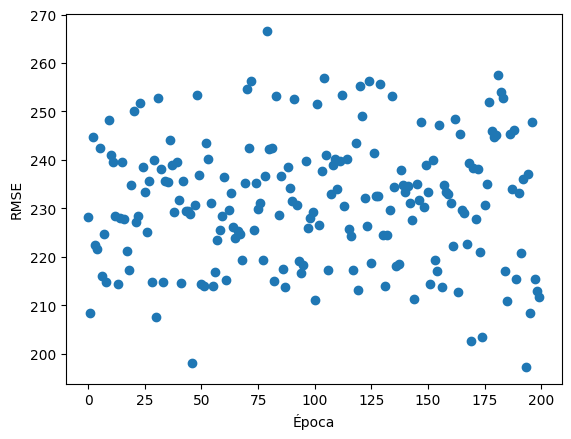

In [128]:
import matplotlib.pyplot as plt 

plt.scatter(x_plot, y_plot)
plt.xlabel("Época")
plt.ylabel("RMSE")

print(min(y_plot))

In [127]:
normalizador = StandardScaler()

sepal_lenght = df["sepal_length"].values.reshape(-1,1)
sepal_width = df["sepal_width"].values.reshape(-1,1)
petal_lenght = df["petal_length"].values.reshape(-1,1)
petal_width = df["petal_width"].values.reshape(-1,1)

normalizador.fit(sepal_lenght)
normalizador.fit(sepal_width)
normalizador.fit(petal_lenght)
normalizador.fit(petal_width)

sepal_lenght = normalizador.transform(sepal_lenght)
sepal_width = normalizador.transform(sepal_width)
petal_lenght = normalizador.transform(petal_lenght)
petal_width = normalizador.transform(petal_width)

sepal_lenght = sepal_lenght.tolist()
sepal_width = sepal_width.tolist()
petal_lenght = petal_lenght.tolist()
petal_width = petal_width.tolist()

x = []
for i, j, k in zip(sepal_lenght, sepal_width, petal_lenght):
  for sep_l, sep_w, pet_l in zip(i, j, k):
    x.append([sep_l, sep_w, pet_l])
        
y_true = []
for i in petal_width:
    for j in i:
        y_true.append(j)

print(x)
print(y_true)

[[5.134532735217001, 3.028417786572188, 0.26414191647586993], [4.8712683666364, 2.370256865120684, 0.26414191647586993], [4.608003998055798, 2.6335212337012854, 0.13250973218556925], [4.476371813765497, 2.501889049410985, 0.3957741007661709], [5.002900550926701, 3.160049970862489, 0.26414191647586993], [5.529429288087905, 3.5549465237333915, 0.6590384693467726], [4.476371813765497, 2.896785602281887, 0.26414191647586993], [5.002900550926701, 2.896785602281887, 0.3957741007661709], [4.213107445184896, 2.238624680830383, 0.26414191647586993], [4.8712683666364, 2.501889049410985, 0.3957741007661709], [5.529429288087905, 3.29168215515279, 0.3957741007661709], [4.739636182346099, 2.896785602281887, 0.5274062850564719], [4.739636182346099, 2.370256865120684, 0.26414191647586993], [4.081475260894595, 2.370256865120684, -0.1307546363950324], [6.055958025249107, 3.686578708023692, 0.0008775478952682834], [5.924325840958807, 4.213107445184896, 0.3957741007661709], [5.529429288087905, 3.554946523